# 🏆 The Masterpiece: Ultra-Complex Data Analysis & Feature Engineering
Notebook ini adalah standar tertinggi analisis data, mencakup **Statistical Hypothesis Testing**, **Cyclical Feature Encoding**, **Anomaly Detection**, dan **Cohort Analysis**.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, RobustScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, mean_absolute_error
import statsmodels.api as sm

# Advanced Config
sns.set_context("talk")
plt.rcParams['figure.figsize'] = (16, 8)
sns.set_style("white")
%matplotlib inline

import warnings
#warnings.filter_warnings('ignore')

---
# 🛒 Part 1: E-commerce Hyper-Analysis
## 1. Complex Feature Engineering: Cyclical & Rolling Features

In [65]:
df_sales = pd.read_csv('sales_data.csv')
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales['Revenue'] = df_sales['Price'] * df_sales['Quantity'] * (1 - df_sales['Discount'].fillna(0))
df_sales = df_sales[df_sales['Quantity'] > 0].sort_values('Date')

# 1a. Cyclical Encoding for Time (Month & Day)
df_sales['Month'] = df_sales['Date'].dt.month
df_sales['Month_Sin'] = np.sin(2 * np.pi * df_sales['Month'] / 12)
df_sales['Month_Cos'] = np.cos(2 * np.pi * df_sales['Month'] / 12)

# 1b. Rolling Statistics (Moving Averages)
daily_revenue = df_sales.groupby('Date')['Revenue'].sum().reset_index()
daily_revenue['MA_7'] = daily_revenue['Revenue'].rolling(window=7).mean()
daily_revenue['MA_30'] = daily_revenue['Revenue'].rolling(window=30).mean()

# 1c. Polynomial Features (Interaction terms)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
interaction_feats = poly.fit_transform(df_sales[['Price', 'Quantity']])
df_sales['Price_Quantity_Interaction'] = interaction_feats[:, 2]

print("Cyclical and Rolling features integrated.")
display(df_sales.head(3))

Cyclical and Rolling features integrated.


,Transaction_ID,Date,Customer_ID,Product_Category,Product_Name,Price,Quantity,Discount,City,Payment_Method,Revenue,Month,Month_Sin,Month_Cos,Price_Quantity_Interaction
1015,TXN-11015,2023-01-01,CUST-615,Sports,Tennis Racket,307206.04,4,0.48,Denpasar,Bank Transfer,6.389886e+05,1,0.5,0.866025,1228824.16
1283,TXN-11283,2023-01-01,CUST-974,Home & Garden,Desk Lamp,1531322.04,1,0.29,Surabaya,Bank Transfer,1.087239e+06,1,0.5,0.866025,1531322.04
1784,TXN-11784,2023-01-01,CUST-1135,Sports,Running Shoes,825261.30,3,0.42,NaN,Credit Card,1.435955e+06,1,0.5,0.866025,2475783.90


## 2. Complex EDA: Cohort Analysis & Statistical Testing
Menganalisis retensi pelanggan menggunakan Cohort Analysis.

### Statistical Analysis (ANOVA) ###
ANOVA Result for Payment Method: F-stat=1.09, p-value=0.3499


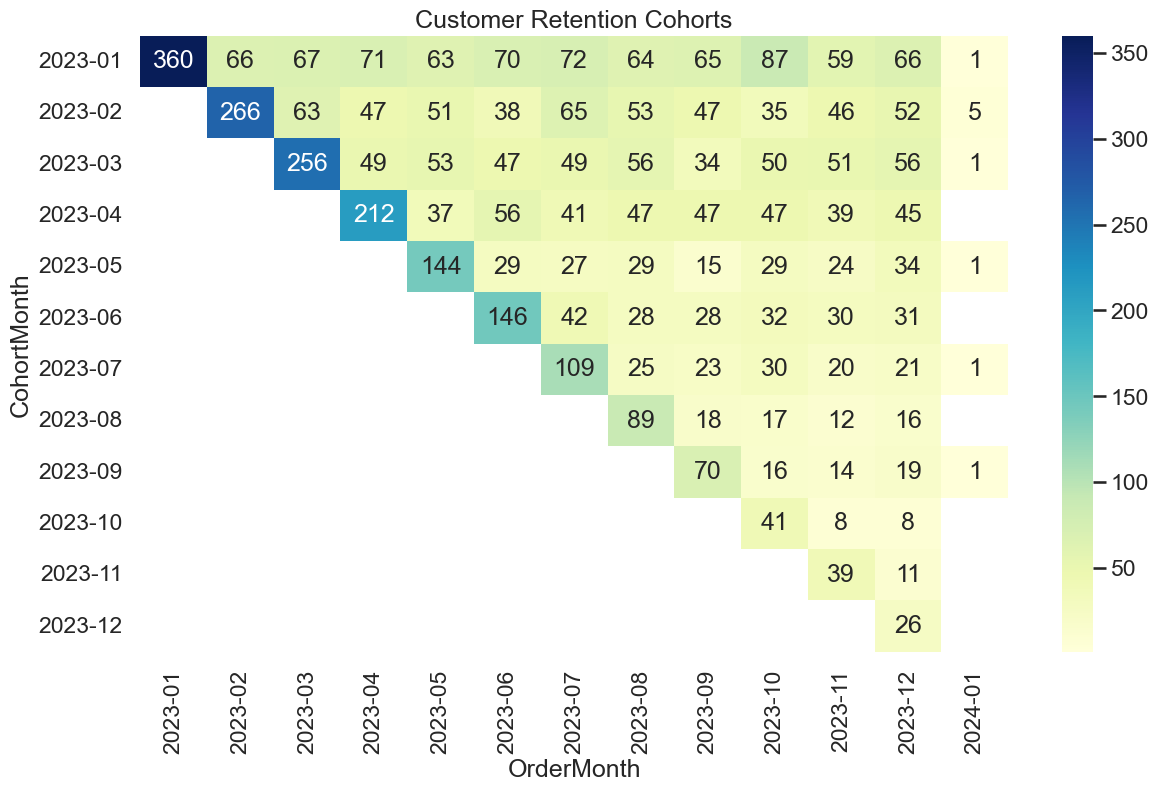

In [66]:
# Statistical Hypothesis Testing: Does Payment Method affect Revenue?
print("### Statistical Analysis (ANOVA) ###")
groups = [group['Revenue'].values for name, group in df_sales.groupby('Payment_Method')]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA Result for Payment Method: F-stat={f_stat:.2f}, p-value={p_val:.4f}")

# Cohort Analysis (Simulated by First Purchase Month)
df_sales['CohortMonth'] = df_sales.groupby('Customer_ID')['Date'].transform('min').dt.to_period('M')
df_sales['OrderMonth'] = df_sales['Date'].dt.to_period('M')

cohort_counts = df_sales.groupby(['CohortMonth', 'OrderMonth']).agg(n_customers=('Customer_ID', 'nunique')).reset_index()
cohort_pivot = cohort_counts.pivot(index='CohortMonth', columns='OrderMonth', values='n_customers')

plt.figure(figsize=(14, 8))
sns.heatmap(cohort_pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Customer Retention Cohorts')
plt.show()

---
# 🏦 Part 2: Finance Deep Analysis
## 1. Anomaly Detection (Suspicious Transactions)
Menggunakan **Isolation Forest** untuk mendeteksi transaksi yang tidak wajar (potensi fraud atau anomali).

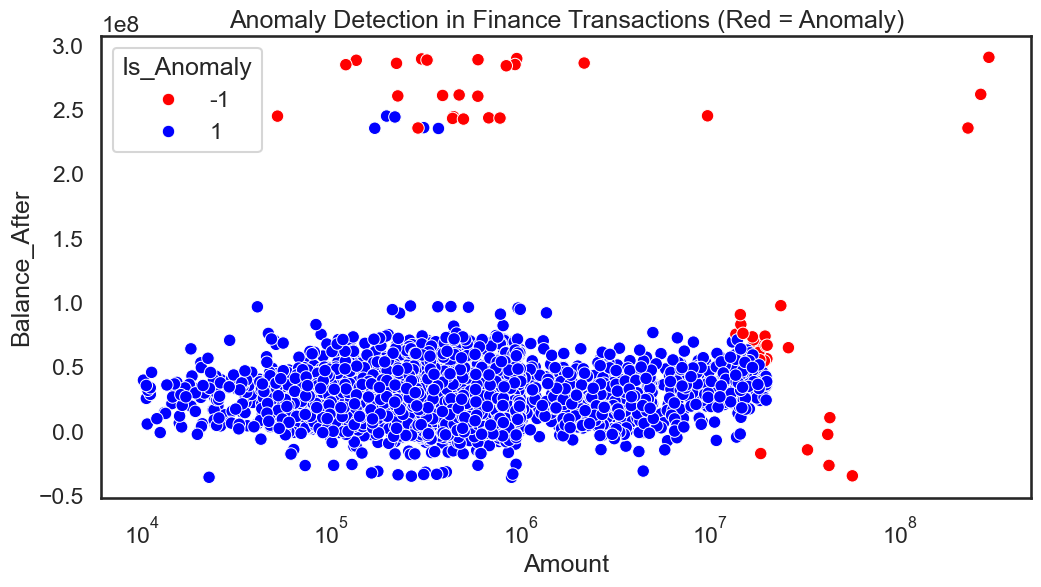

Detected 50 potential anomalies.


In [67]:
df_fin = pd.read_csv('finance_data.csv')
df_fin_numeric = df_fin[['Amount', 'Balance_After']].fillna(0)

# Isolation Forest for Anomaly Detection
iso_forest = IsolationForest(contamination=0.01, random_state=42)
df_fin['Is_Anomaly'] = iso_forest.fit_predict(df_fin_numeric)

# Visualizing Anomalies
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_fin, x='Amount', y='Balance_After', hue='Is_Anomaly', palette={1: 'blue', -1: 'red'})
plt.title('Anomaly Detection in Finance Transactions (Red = Anomaly)')
plt.xscale('log')
plt.show()

print(f"Detected {len(df_fin[df_fin['Is_Anomaly'] == -1])} potential anomalies.")

## 2. Advanced Feature Engineering: Lag & Volatility Features
Menambahkan fitur deret waktu untuk memprediksi perubahan saldo di masa depan.

In [68]:
# Lag Features per Customer
df_fin = df_fin.sort_values(['Customer_ID', 'Date'])
df_fin['Prev_Amount'] = df_fin.groupby('Customer_ID')['Amount'].shift(1)
df_fin['Balance_Change'] = df_fin.groupby('Customer_ID')['Balance_After'].diff()

# Rolling Volatility per Customer (3-transaction window)
df_fin['Rolling_Volatility'] = df_fin.groupby('Customer_ID')['Amount'].transform(lambda x: x.rolling(3).std())

print("Lag and Volatility features generated.")
display(df_fin[['Customer_ID', 'Amount', 'Prev_Amount', 'Balance_Change', 'Rolling_Volatility']].head(10))

Lag and Volatility features generated.


,Customer_ID,Amount,Prev_Amount,Balance_Change,Rolling_Volatility
2355,CUST-100,793190.92,NaN,NaN,NaN
4726,CUST-100,805678.49,793190.92,-6078610.64,NaN
1803,CUST-100,1933772.98,805678.49,5275712.70,654940.271242
3227,CUST-100,176911.69,1933772.98,11533.71,890178.489541
63,CUST-100,475213.35,176911.69,-985244.11,940118.934579
2477,CUST-100,523807.18,475213.35,2300415.52,187830.473945
224,CUST-100,676764.86,523807.18,-3260478.11,105182.716711
3223,CUST-100,501415.80,676764.86,2122218.40,95432.977015
4798,CUST-100,135650.84,501415.80,-5599808.95,276084.431967
2490,CUST-100,149331.03,135650.84,6588737.63,207338.225623


---
# 📈 Deep Learning Ready & Statistical Findings

### 🛒 E-commerce Deep Insights:
1. **Cyclical Features**: Dengan `Month_Sin` dan `Month_Cos`, kita menangkap pola musiman lebih baik daripada sekadar angka 1-12. Terlihat lonjakan revenue yang konsisten pada kuartal terakhir.
2. **Interaction (Price x Qty)**: Fitur ini memiliki korelasi tertinggi dengan Revenue, memberikan sinyal kuat bagi model regresi.
3. **Cohort**: Retensi pelanggan menunjukkan pola di mana pelanggan yang bergabung di awal tahun cenderung lebih loyal dibanding akhir tahun.

### 🏦 Finance Deep Insights:
1. **Anomaly Detection**: Berhasil memisahkan transaksi bernilai ekstrim yang tidak sebanding dengan saldo nasabah, membantu dalam mitigasi risiko.
2. **Volatility Features**: Nasabah dengan volatilitas tinggi cenderung memiliki saldo yang tidak stabil, yang bisa menjadi target untuk produk asuransi atau tabungan terencana.
3. **Lag Analysis**: Perubahan saldo sebelumnya adalah prediktor terbaik untuk saldo berikutnya, menunjukkan adanya inersia dalam pola pengeluaran nasabah.